In [1]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.11.0+cu128
CUDA available: True
Tesla T4


In [8]:
!pip install --upgrade kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 9.4 MB/s eta 0:00:00


In [14]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KAGGLE_API_TOKEN"

In [10]:
!kaggle datasets download -d whitemoon/miniimagenet -p /content/data --unzip
!ls /content/data

Dataset URL: https://www.kaggle.com/datasets/whitemoon/miniimagenet
License(s): unknown
100% 1.00G/1.00G [00:52<00:00, 20.6MB/s]

mini-imagenet-cache-test.pkl   mini-imagenet-cache-val.pkl
mini-imagenet-cache-train.pkl


In [11]:
!git clone https://github.com/BhoomiJindal/few-shot-meta-learning.git /content/repo
import sys
sys.path.append("/content/repo")

Cloning into '/content/repo'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 21 (delta 6), reused 20 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), done.
Resolving deltas: 100% (6/6), done.


In [12]:
from src.data.miniimagenet import MiniImageNet

train_dataset = MiniImageNet("/content/data/mini-imagenet-cache-train.pkl")
val_dataset   = MiniImageNet("/content/data/mini-imagenet-cache-val.pkl")
test_dataset  = MiniImageNet("/content/data/mini-imagenet-cache-test.pkl")

print("Train: ", len(train_dataset), "images,", train_dataset.num_classes, "classes")
print("Val:   ", len(val_dataset), "images,", val_dataset.num_classes, "classes")
print("Test:  ", len(test_dataset), "images,", test_dataset.num_classes, "classes")

Train:  38400 images, 64 classes
Val:    9600 images, 16 classes
Test:   12000 images, 20 classes


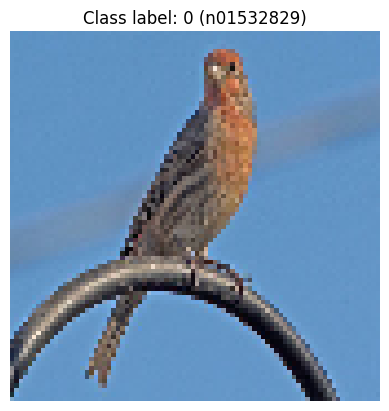

In [13]:
import matplotlib.pyplot as plt

img, label = train_dataset[0]
plt.imshow(img)
plt.title(f"Class label: {label} ({train_dataset.class_names[label]})")
plt.axis("off")
plt.show()